# Загрузка данных и библиотек
---

In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
from sklearn.base import clone
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, RegressorMixin

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt
import seaborn as sns
import copy

RANDOM_STATE = 0xDEF

In [3]:
train_raw = pd.read_csv('./data/train.csv')
test_raw = pd.read_csv('./data/test.csv')

train = train_raw.copy()
test = test_raw.copy()

# EDA
---

In [4]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Посмотрим на распределение таргета `SalePrice`

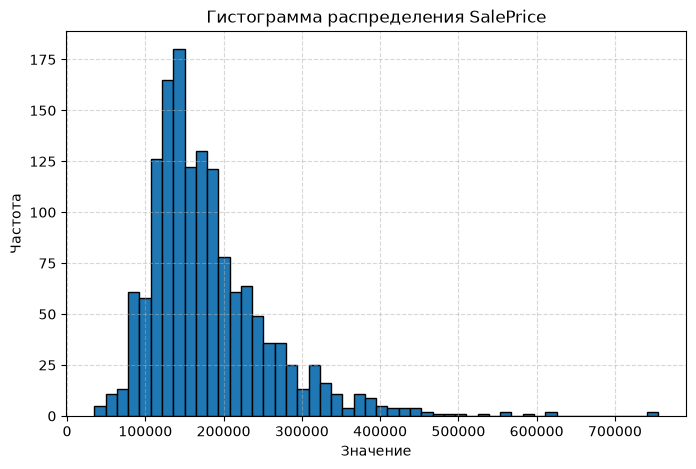

In [5]:
plt.figure(figsize=(8, 5))
plt.hist(train['SalePrice'], bins=50, edgecolor='black')

plt.title('Гистограмма распределения SalePrice')
plt.xlabel('Значение')
plt.ylabel('Частота')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Видим, что распределение нессиметрично, попробуем взять log от величины

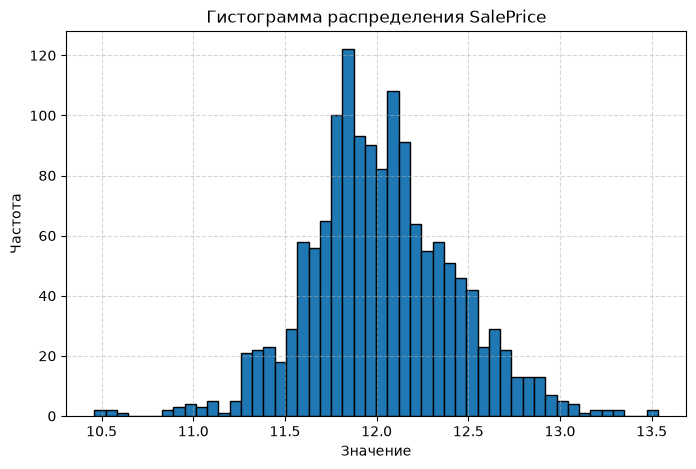

In [6]:
train['SalePrice_log'] = np.log1p(train['SalePrice'])

plt.figure(figsize=(8, 5))
plt.hist(train['SalePrice_log'], bins=50, edgecolor='black')

plt.title('Гистограмма распределения SalePrice')
plt.xlabel('Значение')
plt.ylabel('Частота')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

График стал более симметричным и похожим на нормальное распределение

C:\Users\MSI\AppData\Local\Temp\ipykernel_12208\1648524903.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(train['SalePrice_log'], vert=False, patch_artist=True)


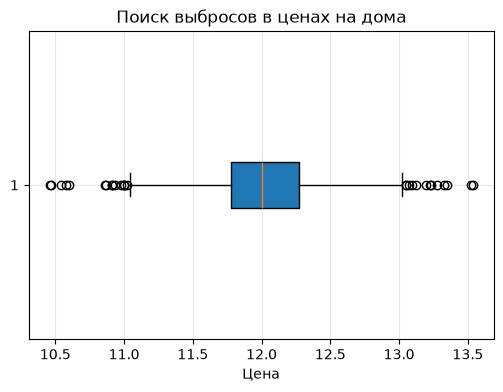

In [7]:
plt.figure(figsize=(6, 4))
plt.boxplot(train['SalePrice_log'], vert=False, patch_artist=True)
plt.title('Поиск выбросов в ценах на дома')
plt.xlabel('Цена')
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
# Расчет Z-score для каждой цены
train['Z_Score'] = (train['SalePrice_log'] - train['SalePrice_log'].mean()) / train['SalePrice_log'].std()

# Находим выбросы (где Z-score больше 3 или меньше -3)
outliers_z = train[train['Z_Score'].abs() > 3]
print("Выбросы по методу Z-score:")
print(outliers_z[['SalePrice_log']])


Выбросы по методу Z-score:
      SalePrice_log
30        10.596660
440       13.226725
495       10.460271
533       10.579005
691       13.534474
803       13.275829
898       13.323929
916       10.471978
968       10.542733
1046      13.229570
1169      13.345509
1182      13.521141


In [9]:
outliers_z[['SalePrice', 'Neighborhood', 'SaleCondition']].sort_values(by='SalePrice')

,SalePrice,Neighborhood,SaleCondition
495,34900,IDOTRR,Abnorml
916,35311,IDOTRR,Abnorml
968,37900,OldTown,Abnorml
533,39300,BrkSide,Normal
30,40000,IDOTRR,Normal
440,555000,NridgHt,Normal
1046,556581,StoneBr,Partial
803,582933,NridgHt,Partial
898,611657,NridgHt,Partial
1169,625000,NoRidge,Normal


### Анализ пропусков

In [10]:
with pd.option_context('display.max_rows', None):
    print(train.isna().sum()[train.isna().sum() > 0].sort_values())

Electrical         1
MasVnrArea         8
BsmtCond          37
BsmtFinType1      37
BsmtQual          37
BsmtExposure      38
BsmtFinType2      38
GarageType        81
GarageQual        81
GarageFinish      81
GarageCond        81
GarageYrBlt       81
LotFrontage      259
FireplaceQu      690
MasVnrType       872
Fence           1179
Alley           1369
MiscFeature     1406
PoolQC          1453
dtype: int64


Рассмотрим пропуски для `PoolQC`, вполне возможно пропуски означают отсутствие объекта

In [11]:
print((train[train['PoolQC'].isna()].index != train[train['PoolArea'] == 0].index).sum())

0


ВЫВОД: пропуски в `PoolQC` означают отсутствие объекта

In [12]:
train['MiscFeature'].unique()

<StringArray>
[nan, 'Shed', 'Gar2', 'Othr', 'TenC']
Length: 5, dtype: str

# Предобработка данных
---

In [13]:
train = train_raw.copy()
test  = test_raw.copy()

df = pd.concat([train, test], sort=False).reset_index(drop=True)
train_mask = df['SalePrice'].notna()

### Заполнение пропусков

In [14]:
total = df.isna().sum()
percent = np.round((df.isna().sum() / df.shape[0]) * 100, 2)

missing_df = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_df.drop('SalePrice', inplace=True)
display(missing_df[missing_df['Total'] > 0].sort_values(by='Total', ascending=False))

,Total,Percent
PoolQC,2909,99.66
MiscFeature,2814,96.40
Alley,2721,93.22
Fence,2348,80.44
MasVnrType,1766,60.50
FireplaceQu,1420,48.65
LotFrontage,486,16.65
GarageQual,159,5.45
GarageYrBlt,159,5.45
GarageCond,159,5.45


Для категориальных признаков отсутствие объекта вместо `NaN` заполним строкой `"None"`

In [15]:
none_columns_categorical = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType',
]
for col in none_columns_categorical:
    df[col] = df[col].fillna('None')

А для числовых признаков - заполним нулём

In [16]:
none_columns_numeric = [
    'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea',
]
for col in none_columns_numeric:
    df[col] = df[col].fillna(0)

Пропуски `GarageYrBlt` можно заменить годом постройки дома `YearBuilt`

In [17]:
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['YearBuilt'])

Пропуски `LotFrontage` можно заменить медианой внутри `Neighborhood`

In [18]:
train_medians = df[train_mask].groupby('Neighborhood')['LotFrontage'].median()
df['LotFrontage'] = df['LotFrontage'].fillna(df['Neighborhood'].map(train_medians))
df['LotFrontage'] = df['LotFrontage'].fillna(df.loc[train_mask, 'LotFrontage'].median())

Оставшиеся единичные пропуски можно заменить модой

In [19]:
mode_fill_columns = ['MSZoning', 'Utilities', 'Functional', 'Exterior1st', 'Exterior2nd', 'Electrical', 'KitchenQual', 'SaleType']
for col in mode_fill_columns:
    train_mode = df.loc[train_mask, col].mode()[0]
    df[col] = df[col].fillna(train_mode)

### Преобразования

Переведем `MSSubClass` в категориальный признак

In [20]:
df['MSSubClass'] = df['MSSubClass'].astype('category')

Рассмотрим статистику по категориальным признакам

In [21]:
categorical_stats = df.describe(include=['object', 'category'])

with pd.option_context('display.max_columns', None):
    display(categorical_stats)

C:\Users\MSI\AppData\Local\Temp\ipykernel_12208\2093459671.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_stats = df.describe(include=['object', 'category'])


,MSSubClass,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,CentralAir,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919
unique,16,5,2,3,4,4,2,5,3,25,9,8,5,8,6,8,15,16,4,4,5,6,5,5,5,7,7,6,5,2,5,4,7,6,7,4,6,6,3,4,5,5,9,6
top,20,RL,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,Gable,CompShg,VinylSd,VinylSd,None,TA,TA,PConc,TA,TA,No,Unf,Unf,GasA,Ex,Y,SBrkr,TA,Typ,None,Attchd,Unf,TA,TA,Y,None,None,None,WD,Normal
freq,1079,2269,2907,2721,1859,2622,2918,2133,2778,443,2511,2889,2425,1471,2310,2876,1026,1015,1766,1798,2538,1308,1283,2606,1904,851,2493,2874,1493,2723,2672,1493,2719,1420,1723,1230,2604,2654,2641,2909,2348,2814,2526,2402


In [22]:
exclude_columns = ['Id', 'SalePrice']

THRESHOLD = 6

num_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_features = [col for col in num_features if col not in exclude_columns]

cat_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
cat_columns = [col for col in cat_columns if col not in exclude_columns]

ohe_features = []
target_features = []

for col in cat_columns:
    n_unique = df.loc[train_mask, col].nunique()
    if n_unique <= THRESHOLD:
        ohe_features.append(col)
    else:
        target_features.append(col)

C:\Users\MSI\AppData\Local\Temp\ipykernel_12208\3542493421.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()


In [23]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def target_encode_cv(df, train_mask, target_features, y, cv, smoothing=10):
    """
    Честный (без утечки) target encoding для категориальных признаков высокой кардинальности.

    Train: каждая строка получает OOF-закодированное значение — среднее по таргету
    внутри категории, посчитанное БЕЗ фолда, в который попала сама строка.
    Test: кодируется средним по категории, посчитанным на всём train.

    smoothing сглаживает редкие категории к глобальному среднему:
    encoded = (count * category_mean + smoothing * global_mean) / (count + smoothing)
    """
    df = df.copy()
    global_mean = y.mean()
    train_idx = df.index[train_mask]
    test_idx = df.index[~train_mask]

    for col in target_features:
        encoded = pd.Series(index=df.index, dtype=float)

        # --- Train: честные OOF-значения ---
        for tr_pos, val_pos in cv.split(train_idx):
            fold_train_idx = train_idx[tr_pos]
            fold_val_idx = train_idx[val_pos]

            stats = pd.DataFrame({'y': y.loc[fold_train_idx], 'cat': df.loc[fold_train_idx, col]}) \
                        .groupby('cat')['y'].agg(['mean', 'count'])
            smoothed = (stats['count'] * stats['mean'] + smoothing * global_mean) / (stats['count'] + smoothing)

            encoded.loc[fold_val_idx] = df.loc[fold_val_idx, col].map(smoothed)

        # категории, не встретившиеся в конкретном обучающем фолде, — глобальным средним
        encoded.loc[train_idx] = encoded.loc[train_idx].fillna(global_mean)

        # --- Test: кодируем средним по всему train ---
        stats_full = pd.DataFrame({'y': y, 'cat': df.loc[train_idx, col]}).groupby('cat')['y'].agg(['mean', 'count'])
        smoothed_full = (stats_full['count'] * stats_full['mean'] + smoothing * global_mean) / (stats_full['count'] + smoothing)
        encoded.loc[test_idx] = df.loc[test_idx, col].map(smoothed_full).fillna(global_mean)

        df[col + '_te'] = encoded

    return df.drop(columns=target_features)

In [24]:
df = df.drop(columns=['Id'])
df_cat = df.copy()
df = pd.get_dummies(df, columns=ohe_features)
df = target_encode_cv(df, train_mask, target_features, y=df.loc[train_mask, 'SalePrice'], cv=cv, smoothing=10)

In [25]:
train, test = df[train_mask].copy(), df[~train_mask].copy()
train_cat, test_cat = df_cat[train_mask].copy(), df_cat[~train_mask].copy()
test = test.drop(columns=['SalePrice'])
test_cat = test_cat.drop(columns=['SalePrice'])

X = train.drop('SalePrice', axis=1)
y = train['SalePrice']
X_cat = train_cat.drop('SalePrice', axis=1)
y_cat = train_cat['SalePrice']

# Classic ML
---

Функция для обучения моделей

In [26]:
def run_model(name, estimator, X, y, cv, needs_scaling=False, fit_params=None, stats=None):
    """ Честная OOF-оценка + финальная модель на 100% данных. """
    fit_params = fit_params or {}
    y_log = np.log1p(y)
    oof_preds = np.zeros(len(y))
    fold_scores = []

    for train_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y_log.iloc[train_idx], y_log.iloc[val_idx]

        if needs_scaling:
            scaler = StandardScaler()
            X_tr, X_val = scaler.fit_transform(X_tr), scaler.transform(X_val)

        model = clone(estimator)
        model.fit(X_tr, y_tr, **fit_params)

        fold_pred = model.predict(X_val)
        oof_preds[val_idx] = fold_pred
        fold_scores.append(root_mean_squared_error(y_val, fold_pred))

    total_rmse = root_mean_squared_error(y_log, oof_preds)
    if stats is not None:
        stats[name] = total_rmse

    msg = f'{name}: OOF RMSE(log) = {total_rmse:.4f} | by folds: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}'
    print(msg)

    scaler_full = StandardScaler().fit(X) if needs_scaling else None
    X_full = scaler_full.transform(X) if scaler_full else X
    final_model = clone(estimator).fit(X_full, y_log, **fit_params)

    return {
        'oof_preds': oof_preds, 'model': final_model, 'scaler': scaler_full, 'fold_scores': fold_scores}

### Dummy Regressor - baseline

In [27]:
stats_stage1 = {}
results_stage1 = {}

results_stage1['dummy'] = run_model("DummyRegressor", DummyRegressor(strategy='mean'), X, y, cv, stats=stats_stage1)
dummy_model = results_stage1['dummy']['model']

DummyRegressor: OOF RMSE(log) = 0.3996 | by folds: 0.3993 ± 0.0160


### Linear Regression

In [28]:
def get_tuned_linear_regression(X, y, cv, verbose=True):
    y_log = np.log1p(y)
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(max_iter=20000, tol=1e-3, random_state=RANDOM_STATE))
    ])
    
    param_grid = {
        'model__alpha': np.logspace(-4, 2, 15),
        'model__l1_ratio': [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
    }

    search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
    search.fit(X, y_log)
    if verbose:
        print('Linear Regression (ElasticNet):')
        print(pd.DataFrame.from_dict(search.best_params_, orient='index', columns=['value']), end='\n')
        
    return search.best_estimator_.named_steps['model']

lr_tuned = get_tuned_linear_regression(X, y, cv)

Linear Regression (ElasticNet):
                   value
model__alpha     0.26827
model__l1_ratio  0.00000


In [29]:
results_stage1['lr'] = run_model('LinearRegression', lr_tuned, X, y, cv, needs_scaling=True, stats=stats_stage1)
lr_model = results_stage1['lr']['model']

LinearRegression: OOF RMSE(log) = 0.1468 | by folds: 0.1451 ± 0.0224


### KNN

In [30]:
def get_tuned_knn(X, y, cv, verbose=True):
    y_log = np.log1p(y)
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsRegressor())
    ])
    param_grid = [
        {'model__n_neighbors': np.arange(1, 50), 'model__weights': ['uniform', 'distance'], 'model__metric': ['euclidean', 'manhattan']},
        {'model__n_neighbors': np.arange(1, 50), 'model__weights': ['uniform', 'distance'], 'model__metric': ['minkowski'], 'model__p': [1, 2, 3]},
    ]
    search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
    search.fit(X, y_log)
    if verbose:
        print('KNeighborsRegressor:')
        print(pd.DataFrame.from_dict(search.best_params_, orient='index', columns=['value']), end='\n')
    return search.best_estimator_.named_steps['model']

knn_tuned = get_tuned_knn(X, y, cv)

KNeighborsRegressor:
                        value
model__metric       manhattan
model__n_neighbors          7
model__weights       distance


In [31]:
results_stage1['knn'] = run_model('KNeighborsRegressor', knn_tuned, X, y, cv, needs_scaling=True, stats=stats_stage1)
knn_model = results_stage1['knn']['model']

KNeighborsRegressor: OOF RMSE(log) = 0.1825 | by folds: 0.1823 ± 0.0096


### Decision Tree

In [32]:
def get_tuned_decision_tree(X, y, cv, verbose=True):
    y_log = np.log1p(y)
    param_grid = {
        'criterion': ['squared_error', 'absolute_error', 'poisson'],
        'max_depth': [None, 2, 3, 4, 5, 7, 10, 12, 15], 
        'min_samples_split': np.arange(2, 30, 2),
        'min_samples_leaf': np.arange(1, 20, 2),
        'max_features': [None, 'sqrt', 'log2', 0.5, 0.7] 
    }

    search = RandomizedSearchCV(DecisionTreeRegressor(random_state=RANDOM_STATE), 
                                param_grid, 
                                n_iter=300, 
                                cv=cv, 
                                scoring='neg_root_mean_squared_error', 
                                random_state=RANDOM_STATE, 
                                n_jobs=-1)
    search.fit(X, y_log)
    if verbose:
        print('DecisionTreeRegressor:')
        print(pd.DataFrame.from_dict(search.best_params_, orient='index', columns=['value']), end='\n')
    return search.best_estimator_

tree_tuned = get_tuned_decision_tree(X, y, cv)

DecisionTreeRegressor:
                            value
min_samples_split              16
min_samples_leaf               13
max_features                 None
max_depth                      10
criterion          absolute_error


In [33]:
results_stage1['tree'] = run_model('DecisionTreeRegressor', tree_tuned, X, y, cv, needs_scaling=False, stats=stats_stage1)
tree_model = results_stage1['tree']['model']

DecisionTreeRegressor: OOF RMSE(log) = 0.1796 | by folds: 0.1793 ± 0.0097


### Random Forest

In [34]:
def get_tuned_random_forest(X, y, cv, verbose=True):
    y_log = np.log1p(y)
    param_grid = {
        'criterion': ['squared_error', 'absolute_error', 'poisson'],
        'max_samples': [0.5, 0.7, 0.9, None],
        'max_depth': [2, 3, 4, 5],
        'max_features': ['sqrt', 'log2', 0.4, 0.6],
        'min_samples_split': [2, 4, 5, 7, 10],
        'min_samples_leaf': [1, 2, 4, 5, 7, 10],
    }

    search = RandomizedSearchCV(RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE), 
                                param_grid, 
                                n_iter=100, 
                                cv=cv, 
                                scoring='neg_root_mean_squared_error', 
                                random_state=RANDOM_STATE, 
                                n_jobs=-1)
    search.fit(X, y_log)
    if verbose:
        print('RandomForestRegressor:')
        print(pd.DataFrame.from_dict(search.best_params_, orient='index', columns=['value']), end='\n')
    return search.best_estimator_

rf_tuned = get_tuned_random_forest(X, y, cv)

RandomForestRegressor:
                           value
min_samples_split              7
min_samples_leaf               4
max_samples                  0.7
max_features                 0.4
max_depth                      5
criterion          squared_error


In [35]:
results_stage1['rf'] = run_model('RandomForestRegressor', rf_tuned, X, y, cv, needs_scaling=False, stats=stats_stage1)
rf_model = results_stage1['rf']['model']

RandomForestRegressor: OOF RMSE(log) = 0.1532 | by folds: 0.1529 ± 0.0082


### CatBoost

In [36]:
def get_tuned_catboost(X, y, cv, cat_features, verbose=True):
    y_log = np.log1p(y)
    param_grid = {
        'learning_rate': [0.01, 0.03, 0.05, 0.1],
        'depth': [3, 4, 5, 6, 8],                
        'l2_leaf_reg': [1, 3, 5, 10, 20],
        'random_strength': [0.0, 0.2, 0.5, 1.0],
        'bagging_temperature': [0.0, 0.4, 0.8, 1.0]
    }

    model = CatBoostRegressor(loss_function='RMSE', random_seed=RANDOM_STATE, iterations=300, logging_level='Silent', allow_writing_files=False, cat_features=cat_features)
    cv_splits = list(cv.split(X, y_log))
    search = model.randomized_search(
        param_grid, X=X, y=y_log, cv=cv_splits, n_iter=40,
        partition_random_seed=RANDOM_STATE, verbose=False, plot=False
    )
    if verbose:
        print('CatBoostRegressor:')
        print(pd.DataFrame.from_dict(search['params'], orient='index', columns=['value']), end='\n')
    return model

cb_tuned = get_tuned_catboost(X_cat, y_cat, cv, cat_features=cat_columns)

CatBoostRegressor:
                     value
bagging_temperature   1.00
random_strength       0.00
depth                 3.00
learning_rate         0.05
l2_leaf_reg           1.00


In [37]:
best_params = cb_tuned.get_params()
best_params.pop('cat_features', None)
cb_template = CatBoostRegressor(**best_params)

results_stage1['cb'] = run_model('CatBoostRegressor', cb_template, X_cat, y_cat, cv, fit_params={'cat_features': cat_columns}, needs_scaling=False, stats=stats_stage1)
cb_model = results_stage1['cb']['model']

CatBoostRegressor: OOF RMSE(log) = 0.1291 | by folds: 0.1288 ± 0.0086


### LightGBM

In [38]:
def get_tuned_lightgbm(X, y, cv, verbose=True):
    y_log = np.log1p(y)
    param_grid = {
        'n_estimators': [50, 100, 200],
        'learning_rate': np.linspace(0.01, 0.1, 5),
        'num_leaves': np.arange(5, 20, 3),
        'max_depth': [-1, 3, 5, 7],
        'min_child_samples': [10, 15, 20, 25, 30]
    }

    search = RandomizedSearchCV(LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
                                param_grid, 
                                n_iter=200, 
                                scoring='neg_root_mean_squared_error', 
                                cv=cv, 
                                n_jobs=-1, 
                                random_state=RANDOM_STATE)
    search.fit(X, y_log)
    if verbose:
        print('LGBMRegressor:')
        print(pd.DataFrame.from_dict(search.best_params_, orient='index', columns=['value']), end='\n')
    return search.best_estimator_

lgbm_tuned = get_tuned_lightgbm(X, y, cv)

LGBMRegressor:
                      value
num_leaves          11.0000
n_estimators       200.0000
min_child_samples   15.0000
max_depth           -1.0000
learning_rate        0.0775


In [39]:
results_stage1['lgbm'] = run_model('LGBMRegressor', lgbm_tuned, X, y, cv, needs_scaling=False, stats=stats_stage1)
lgbm_model = results_stage1['lgbm']['model']

LGBMRegressor: OOF RMSE(log) = 0.1276 | by folds: 0.1272 ± 0.0098


In [40]:
def get_tuned_xgboost(X, y, cv, verbose=True):
    y_log = np.log1p(y)
    param_grid = {
        'n_estimators': np.arange(50, 301, 50),
        'learning_rate': np.linspace(0.01, 0.1, 5),
        'max_depth': [3, 4, 5, 6, 7],
        'min_child_weight': [1, 2, 4, 6, 8, 10],
        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0]
    }

    search = RandomizedSearchCV(XGBRegressor(random_state=RANDOM_STATE, eval_metric='rmse', n_jobs=-1), 
                                param_grid, 
                                n_iter=100, 
                                scoring='neg_root_mean_squared_error', 
                                cv=cv, 
                                n_jobs=-1, 
                                random_state=RANDOM_STATE)
    search.fit(X, y_log)
    if verbose:
        print('XGBRegressor:')
        print(pd.DataFrame.from_dict(search.best_params_, orient='index', columns=['value']), end='\n')
    return search.best_estimator_

xgb_tuned = get_tuned_xgboost(X, y, cv)

XGBRegressor:
                    value
subsample           0.700
n_estimators      200.000
min_child_weight    4.000
max_depth           4.000
learning_rate       0.055
colsample_bytree    0.700


In [41]:
results_stage1['xgb'] = run_model('XGBRegressor', xgb_tuned, X, y, cv, needs_scaling=False, stats=stats_stage1)
xgb_model = results_stage1['xgb']['model']

XGBRegressor: OOF RMSE(log) = 0.1260 | by folds: 0.1257 ± 0.0093


# Итоги по Classic ML

In [42]:
def print_sorted_stats(stats):
    stats = dict(sorted(stats.items(), key=lambda x: x[1]))

    print('┌' + '─' * 24 + '┬' + '─' * 14 + '┐')
    print(f"│ {'Classifier':<22} │ {'CV RMSE(log)':<10} │")
    print('├' + '─' * 24 + '┼' + '─' * 14 + '┤')

    for model_name, accuracy in stats.items():
        print(f"│ {model_name:<22} │ {accuracy:<12.4f} │")

    print('└' + '─' * 24 + '┴' + '─' * 14 + '┘')

print_sorted_stats(stats_stage1)

┌────────────────────────┬──────────────┐
│ Classifier             │ CV RMSE(log) │
├────────────────────────┼──────────────┤
│ XGBRegressor           │ 0.1260       │
│ LGBMRegressor          │ 0.1276       │
│ CatBoostRegressor      │ 0.1291       │
│ LinearRegression       │ 0.1468       │
│ RandomForestRegressor  │ 0.1532       │
│ DecisionTreeRegressor  │ 0.1796       │
│ KNeighborsRegressor    │ 0.1825       │
│ DummyRegressor         │ 0.3996       │
└────────────────────────┴──────────────┘


# Deep Learning
---

In [43]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [44]:
X_train, X_val, y_train, y_val = train_test_split(X, np.log1p(y), test_size=0.2, random_state=RANDOM_STATE, shuffle=True)
scaler_nn = StandardScaler()
X_train_scaled = scaler_nn.fit_transform(X_train)
X_val_scaled   = scaler_nn.transform(X_val)
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).to(device)
X_val_tensor   = torch.tensor(X_val_scaled,   dtype=torch.float32).to(device)
y_val_tensor   = torch.tensor(y_val.values,   dtype=torch.float32).to(device)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

### Первая версия

In [45]:
class NN1(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.layer_1 = nn.Linear(input_dim, 16)
        self.layer_2 = nn.Linear(16, 16)
        self.layer_3 = nn.Linear(16, 1)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.layer_1(x)
        x = self.relu(x)
        x = self.layer_2(x)
        x = self.relu(x)
        x = self.layer_3(x)
        return x

input_dim = X_train_tensor.shape[1]
nn1_model = NN1(input_dim).to(device)

In [46]:
criterion = nn.MSELoss()
optimizer = optim.Adam(nn1_model.parameters(), lr=0.001)

In [47]:
EPOCHS = 100
train_losses, val_losses = [], []
train_rmse, val_rmse = [], []

for epoch in range(EPOCHS):
    nn1_model.train()
    train_loss = 0
    train_sq_error = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = nn1_model(X_batch)
        y_batch = y_batch.view(-1, 1)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_sq_error += ((y_pred - y_batch) ** 2).sum().item()

    train_losses.append(train_loss / len(train_loader))
    train_rmse.append((train_sq_error / len(y_train_tensor)) ** 0.5)

    nn1_model.eval()
    with torch.no_grad():
        y_val_pred = nn1_model(X_val_tensor)
        y_val_target = y_val_tensor.view(-1, 1)
        val_loss = criterion(y_val_pred, y_val_target).item()
        val_sq_error = ((y_val_pred - y_val_target) ** 2).sum().item()

    val_losses.append(val_loss)
    val_rmse.append((val_sq_error / len(y_val_tensor)) ** 0.5)
    if (epoch + 1) % 10 == 0:
        print(f'[EPOCH {epoch+1:3}/{EPOCHS}] train_loss: {train_losses[-1]:.4f}, train_rmse: {train_rmse[-1]:.4f} | val_loss: {val_losses[-1]:.4f}, val_rmse: {val_rmse[-1]:.4f}')

[EPOCH  10/100] train_loss: 2.5131, train_rmse: 1.5871 | val_loss: 4.0703, val_rmse: 2.0175
[EPOCH  20/100] train_loss: 1.0600, train_rmse: 1.0331 | val_loss: 2.7838, val_rmse: 1.6685
[EPOCH  30/100] train_loss: 0.5518, train_rmse: 0.7445 | val_loss: 2.2252, val_rmse: 1.4917
[EPOCH  40/100] train_loss: 0.3258, train_rmse: 0.5725 | val_loss: 1.9143, val_rmse: 1.3836
[EPOCH  50/100] train_loss: 0.2152, train_rmse: 0.4642 | val_loss: 1.7585, val_rmse: 1.3261
[EPOCH  60/100] train_loss: 0.1518, train_rmse: 0.3901 | val_loss: 1.6386, val_rmse: 1.2801
[EPOCH  70/100] train_loss: 0.1199, train_rmse: 0.3466 | val_loss: 1.5289, val_rmse: 1.2365
[EPOCH  80/100] train_loss: 0.0825, train_rmse: 0.2875 | val_loss: 1.4546, val_rmse: 1.2061
[EPOCH  90/100] train_loss: 0.0707, train_rmse: 0.2668 | val_loss: 1.4071, val_rmse: 1.1862
[EPOCH 100/100] train_loss: 0.0559, train_rmse: 0.2365 | val_loss: 1.3801, val_rmse: 1.1748


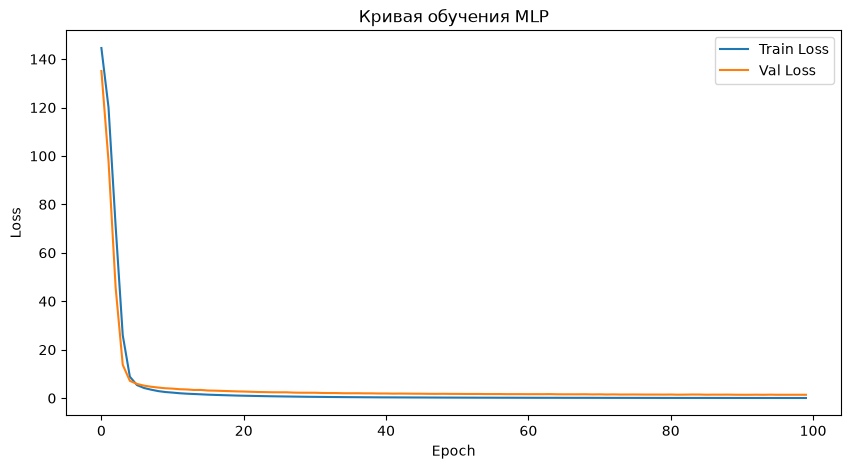

In [48]:
def plot_nn_losses(train_losses, val_losses):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Кривая обучения MLP')
    plt.show()

plot_nn_losses(train_losses, val_losses)

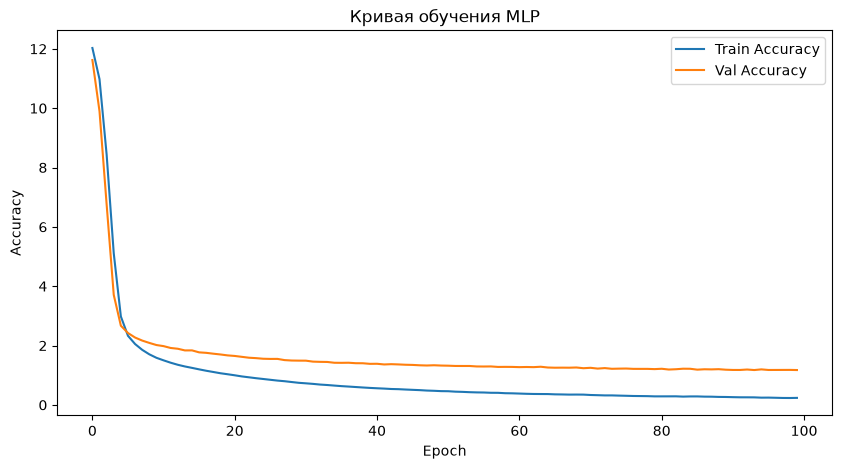

In [49]:
def plot_nn_acc(train_acc, val_acc):
    plt.figure(figsize=(10, 5))
    plt.plot(train_acc, label='Train Accuracy')
    plt.plot(val_acc, label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Кривая обучения MLP')
    plt.show()

plot_nn_acc(train_rmse, val_rmse)

In [50]:
stats_stage1['NN1'] = min(val_rmse)

### Добавляем BatchNorm, DropOut, Early Stopping

In [51]:
class NN2(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.layer_1 = nn.Linear(input_dim, 32)
        self.bn1 = nn.BatchNorm1d(32)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)

        self.layer_2 = nn.Linear(32, 16)
        self.bn2 = nn.BatchNorm1d(16)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.2)

        self.layer_3 = nn.Linear(16, 1)
    
    def forward(self, x):
        x = self.dropout1(self.relu1(self.bn1(self.layer_1(x))))
        x = self.dropout2(self.relu2(self.bn2(self.layer_2(x))))
        return self.layer_3(x)

input_dim = X_train_tensor.shape[1]
nn2_model = NN2(input_dim).to(device)

In [52]:
criterion = nn.MSELoss()
optimizer = optim.Adam(nn2_model.parameters(), lr=0.001, weight_decay=1e-4)

In [53]:
EPOCHS = 200
train_losses, val_losses = [], []
train_rmse, val_rmse = [], []

best_val_loss = float('inf')
best_model_weights = None

for epoch in range(EPOCHS):
    nn2_model.train()
    train_loss = 0
    train_sq_error = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = nn2_model(X_batch)
        y_batch = y_batch.view(-1, 1)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_sq_error += ((y_pred - y_batch) ** 2).sum().item()
    
    train_losses.append(train_loss / len(train_loader))
    train_rmse.append((train_sq_error / len(y_train_tensor)) ** 0.5)

    nn2_model.eval()
    with torch.no_grad():
        y_val_pred = nn2_model(X_val_tensor)
        y_val_target = y_val_tensor.view(-1, 1)
        val_loss = criterion(y_val_pred, y_val_target).item()
        val_sq_error = ((y_val_pred - y_val_target) ** 2).sum().item()

    val_losses.append(val_loss)
    val_rmse.append((val_sq_error / len(y_val_tensor)) ** 0.5)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_weights = copy.deepcopy(nn2_model.state_dict())
    
    if (epoch + 1) % 10 == 0:
        print(f'[EPOCH {epoch+1:3}/{EPOCHS}] train_loss: {train_losses[-1]:.4f}, train_rmse: {train_rmse[-1]:.4f} | val_loss: {val_losses[-1]:.4f}, val_rmse: {val_rmse[-1]:.4f}')        

[EPOCH  10/200] train_loss: 63.5015, train_rmse: 7.9708 | val_loss: 63.5914, val_rmse: 7.9744
[EPOCH  20/200] train_loss: 7.0307, train_rmse: 2.6520 | val_loss: 4.3793, val_rmse: 2.0927
[EPOCH  30/200] train_loss: 4.7480, train_rmse: 2.1755 | val_loss: 1.5376, val_rmse: 1.2400
[EPOCH  40/200] train_loss: 4.1604, train_rmse: 2.0483 | val_loss: 1.4978, val_rmse: 1.2239
[EPOCH  50/200] train_loss: 4.6000, train_rmse: 2.1233 | val_loss: 0.9905, val_rmse: 0.9953
[EPOCH  60/200] train_loss: 4.1980, train_rmse: 2.0519 | val_loss: 1.2464, val_rmse: 1.1164
[EPOCH  70/200] train_loss: 3.4880, train_rmse: 1.8689 | val_loss: 1.0797, val_rmse: 1.0391
[EPOCH  80/200] train_loss: 3.4814, train_rmse: 1.8724 | val_loss: 0.9695, val_rmse: 0.9846
[EPOCH  90/200] train_loss: 3.6026, train_rmse: 1.9001 | val_loss: 1.0311, val_rmse: 1.0154
[EPOCH 100/200] train_loss: 3.2188, train_rmse: 1.7995 | val_loss: 0.8750, val_rmse: 0.9354
[EPOCH 110/200] train_loss: 3.0478, train_rmse: 1.7414 | val_loss: 0.7490, val

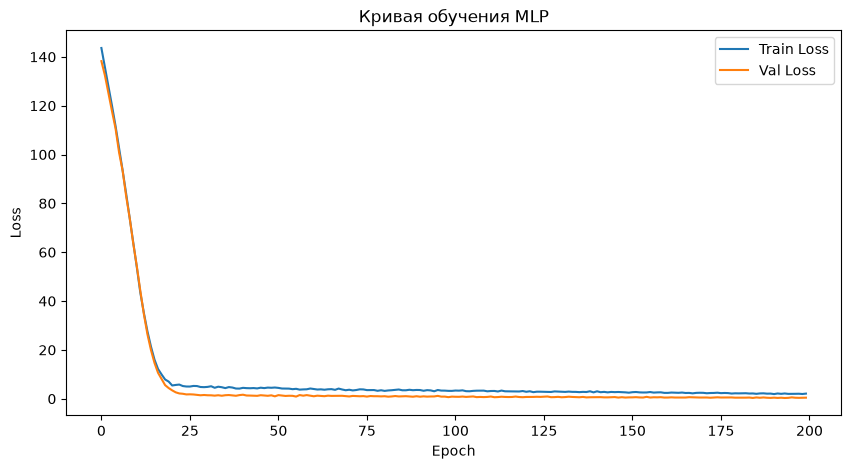

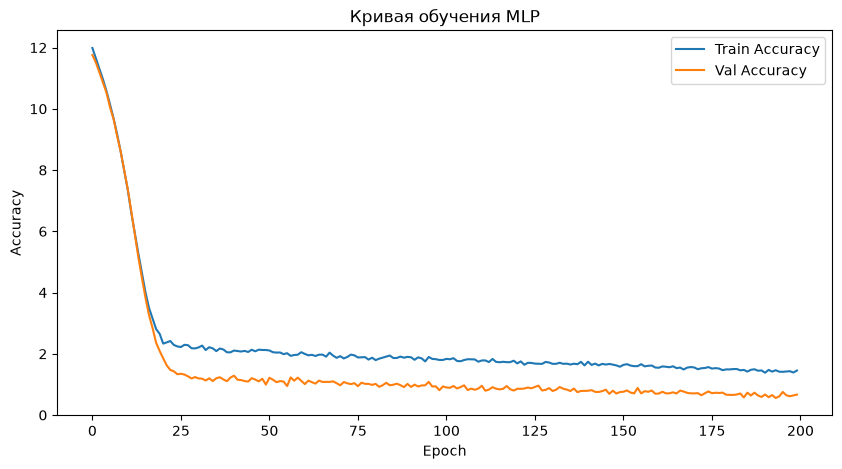

In [54]:
plot_nn_losses(train_losses, val_losses)
plot_nn_acc(train_rmse, val_rmse)

In [55]:
stats_stage1['NN2'] = min(val_rmse)

### Добавляем Scheduler, меняем функции активации

In [56]:
class NN3(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.layer_1 = nn.Linear(input_dim, 32)
        self.bn1 = nn.BatchNorm1d(32)
        self.silu1 = nn.SiLU()
        self.dropout1 = nn.Dropout(0.3)

        self.layer_2 = nn.Linear(32, 16)
        self.bn2 = nn.BatchNorm1d(16)
        self.silu2 = nn.SiLU()
        self.dropout2 = nn.Dropout(0.2)

        self.layer_3 = nn.Linear(16, 1)
    
    def forward(self, x):
        x = self.dropout1(self.silu1(self.bn1(self.layer_1(x))))
        x = self.dropout2(self.silu2(self.bn2(self.layer_2(x))))
        return self.layer_3(x)

input_dim = X_train_tensor.shape[1]
nn3_model = NN3(input_dim).to(device)

In [57]:
criterion = nn.MSELoss()
optimizer = optim.Adam(nn3_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.1)

In [58]:
def get_fitted_nn(nn_model, train_loader, X_val, y_val, scheduler, EPOCHS, early_stopping=True, patience=20, min_delta=1e-4, verbose=True):
    train_losses, val_losses = [], []
    train_rmse, val_rmse = [], []
    if early_stopping:
        best_val_loss = float('inf')
        best_model_weights = None

    patience_counter = 0
    for epoch in range(EPOCHS):
        nn_model.train()
        train_loss = 0
        train_sq_error = 0
        n_train = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = nn_model(X_batch)
            y_batch = y_batch.view(-1, 1)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_sq_error += ((y_pred - y_batch) ** 2).sum().item()
            n_train += y_batch.size(0)

        train_losses.append(train_loss / len(train_loader))
        train_rmse.append((train_sq_error / n_train) ** 0.5)

        nn_model.eval()
        with torch.no_grad():
            y_val_pred = nn_model(X_val)
            y_val_target = y_val.view(-1, 1)
            val_loss = criterion(y_val_pred, y_val_target).item()
            val_sq_error = ((y_val_pred - y_val_target) ** 2).sum().item()

        val_losses.append(val_loss)
        val_rmse.append((val_sq_error / len(y_val)) ** 0.5)

        if early_stopping:
            if val_loss < best_val_loss - min_delta:
                best_val_loss = val_loss
                best_val_rmse = val_rmse[-1]
                best_model_weights = copy.deepcopy(nn_model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    if verbose:
                        print(f'EARLY STOPPING at epoch {epoch+1}')
                    break
        scheduler.step(val_loss)
        if verbose and (epoch + 1) % 10 == 0:
            print(f'[EPOCH {epoch+1:3}/{EPOCHS}] train_loss: {train_losses[-1]:.4f}, train_rmse: {train_rmse[-1]:.4f} | val_loss: {val_losses[-1]:.4f}, val_rmse: {val_rmse[-1]:.4f}')
    if early_stopping:
        nn_model.load_state_dict(best_model_weights)
        nn_model.eval()
    return nn_model, (train_losses, val_losses, train_rmse, val_rmse)


nn3_model, nn_stats = get_fitted_nn(nn3_model, train_loader, X_val_tensor, y_val_tensor, scheduler, EPOCHS=200)
train_losses, val_losses, train_rmse, val_rmse = nn_stats

[EPOCH  10/200] train_loss: 75.4527, train_rmse: 8.6892 | val_loss: 70.7027, val_rmse: 8.4085
[EPOCH  20/200] train_loss: 10.1368, train_rmse: 3.1865 | val_loss: 5.9153, val_rmse: 2.4321
[EPOCH  30/200] train_loss: 7.0558, train_rmse: 2.6570 | val_loss: 1.8673, val_rmse: 1.3665
[EPOCH  40/200] train_loss: 6.1957, train_rmse: 2.4886 | val_loss: 1.1280, val_rmse: 1.0621
[EPOCH  50/200] train_loss: 6.0324, train_rmse: 2.4517 | val_loss: 1.0600, val_rmse: 1.0296
[EPOCH  60/200] train_loss: 5.3819, train_rmse: 2.3162 | val_loss: 1.2031, val_rmse: 1.0969
EARLY STOPPING at epoch 64


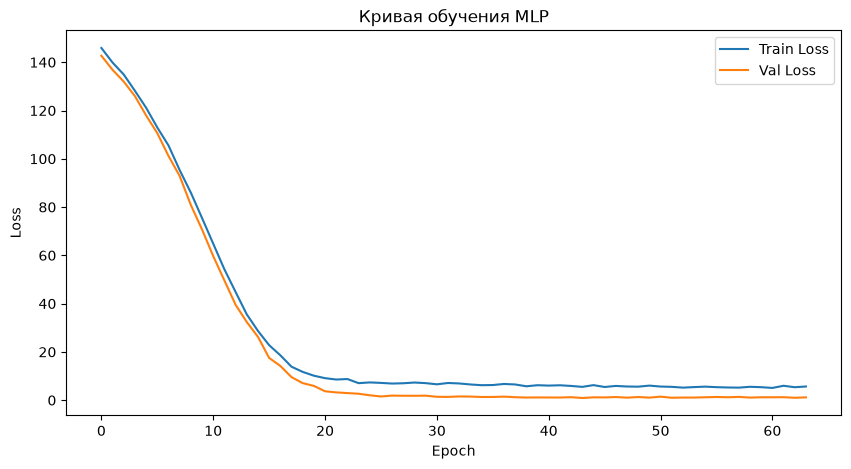

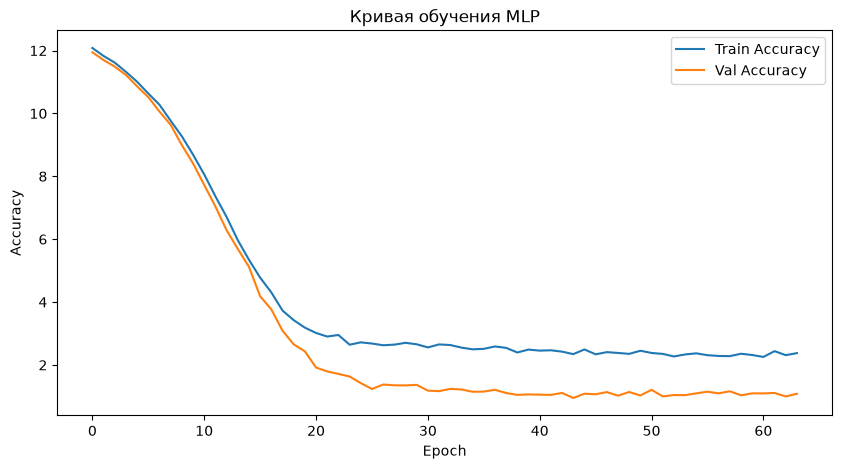

In [59]:
plot_nn_losses(train_losses, val_losses)
plot_nn_acc(train_rmse, val_rmse)

In [60]:
class TorchNNRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, hidden_dim=32, dropout1=0.3, dropout2=0.2,
                 lr=0.005, weight_decay=1e-4, epochs=150, batch_size=32,
                 val_split=0.2, patience=10, min_delta=1e-4, device=None):
        self.hidden_dim = hidden_dim
        self.dropout1 = dropout1
        self.dropout2 = dropout2
        self.lr = lr
        self.weight_decay = weight_decay
        self.epochs = epochs
        self.batch_size = batch_size
        self.val_split = val_split
        self.patience = patience
        self.min_delta = min_delta
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')

    def _build_model(self, input_dim):
        return NN3(input_dim)

    def fit(self, X, y, X_val=None, y_val=None):
        X = np.asarray(X, dtype=np.float32)
        y = np.asarray(y, dtype=np.float32)

        if X_val is None or y_val is None:
            X_train, X_val, y_train, y_val = train_test_split(
                X, y, test_size=self.val_split, random_state=RANDOM_STATE
            )
        else:
            X_train, y_train = X, y

        self.scaler_ = StandardScaler()
        X_train_scaled = self.scaler_.fit_transform(X_train)
        X_val_scaled = self.scaler_.transform(X_val)

        self.model_ = self._build_model(X_train_scaled.shape[1]).to(self.device)
        criterion = nn.MSELoss()
        optimizer = optim.Adam(self.model_.parameters(), lr=self.lr, weight_decay=self.weight_decay)

        train_dataset = TensorDataset(
            torch.tensor(X_train_scaled, dtype=torch.float32).to(self.device),
            torch.tensor(y_train, dtype=torch.float32).to(self.device)
        )
        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)

        X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32).to(self.device)
        y_val_t = torch.tensor(y_val, dtype=torch.float32).to(self.device)

        best_loss = float('inf')
        best_weights = None
        patience_counter = 0

        for epoch in range(self.epochs):
            self.model_.train()
            for X_batch, y_batch in train_loader:
                optimizer.zero_grad()
                loss = criterion(self.model_(X_batch), y_batch.view(-1, 1))
                loss.backward()
                optimizer.step()

            self.model_.eval()
            with torch.no_grad():
                val_pred = self.model_(X_val_t)
                val_loss = criterion(val_pred, y_val_t.view(-1, 1)).item()

            if val_loss < best_loss - self.min_delta:
                best_loss = val_loss
                best_weights = copy.deepcopy(self.model_.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= self.patience:
                    print(f"Early stopping at epoch {epoch+1}")
                    break

        if best_weights is not None:
            self.model_.load_state_dict(best_weights)

        return self

    def predict(self, X):
        X = np.asarray(X, dtype=np.float32)
        X_scaled = self.scaler_.transform(X)
        self.model_.eval()
        with torch.no_grad():
            preds = self.model_(torch.tensor(X_scaled).to(self.device)).cpu().numpy().flatten()
        return preds


nn_tuned = TorchNNRegressor(hidden_dim=32, dropout1=0.3, dropout2=0.2, lr=0.005, epochs=150)
results_stage1['nn'] = run_model('NN3', nn_tuned, X, y, cv, needs_scaling=False, stats=stats_stage1)

Early stopping at epoch 37
Early stopping at epoch 80
Early stopping at epoch 25
Early stopping at epoch 59
Early stopping at epoch 29
NN3: OOF RMSE(log) = 0.6894 | by folds: 0.6676 ± 0.1717
Early stopping at epoch 34


# Итоги по Classic ML & DL

In [61]:
print_sorted_stats(stats_stage1)

┌────────────────────────┬──────────────┐
│ Classifier             │ CV RMSE(log) │
├────────────────────────┼──────────────┤
│ XGBRegressor           │ 0.1260       │
│ LGBMRegressor          │ 0.1276       │
│ CatBoostRegressor      │ 0.1291       │
│ LinearRegression       │ 0.1468       │
│ RandomForestRegressor  │ 0.1532       │
│ DecisionTreeRegressor  │ 0.1796       │
│ KNeighborsRegressor    │ 0.1825       │
│ DummyRegressor         │ 0.3996       │
│ NN2                    │ 0.5569       │
│ NN3                    │ 0.6894       │
│ NN1                    │ 1.1747       │
└────────────────────────┴──────────────┘


# Feature Engineering
---